In [ ]:
# we will use the jikan API To get dataaaaa
# its a good website overall but the demographics and themes fields are mostly empty

# jikan API data scraping code:

import pandas as pd # for data cleaning
import requests # for data scraping
import time # for sleeping to prevent exceeding rate limit
from google.colab import files # for saving the .csv to my computer


# we will be using the jikan API


BASE_URL = "https://api.jikan.moe/v4/anime"
records = []


page = 1


while True:


    res = requests.get(BASE_URL, params={"page": page, "limit": 25})


    if res.status_code != 200:
        print("ERROR IN REQUEST\nStopping Execution...")
        break


    # we will be using .json() to return the data as a python dictionary
    data = res.json()


    for a in data["data"]:
        records.append({
            "mal_id":       a["mal_id"],
            "title":        a["title"],
            "synopsis":     a.get("synopsis", ""),
            "score":        a.get("score"),
            "popularity":   a.get("popularity"),
            "episodes":     a.get("episodes"),
            "status":       a.get("status"),
            "image_url":    a["images"]["jpg"]["image_url"],
            "genres":       "|".join(g["name"] for g in a.get("genres", [])),
            "themes":       "|".join(t["name"] for t in a.get("themes", [])),
            "demographics": "|".join(d["name"] for d in a.get("demographics", [])),
        })


    # if no further pages or limit of 500 pages


    if not data["pagination"]["has_next_page"] or page > 500:
        break


    page += 1


    # to stay under the rate limit
    time.sleep(0.75)


data = pd.DataFrame(records)
data.to_csv("anime_data.csv",index=False)
files.download("anime_data.csv")

In [ ]:
import pandas as pd

df = pd.read_csv("anime_data.csv")
df

,mal_id,title,synopsis,score,popularity,episodes,status,image_url,genres,themes,demographics
0,1,Cowboy Bebop,"Crime is timeless. By the year 2071, humanity ...",8.75,42,26.0,Finished Airing,https://myanimelist.net/images/anime/4/19644.jpg,Action|Award Winning|Sci-Fi,Adult Cast|Space,NaN
1,5,Cowboy Bebop: Tengoku no Tobira,"Another day, another bounty—such is the life o...",8.38,656,1.0,Finished Airing,https://myanimelist.net/images/anime/1439/9348...,Action|Sci-Fi,Adult Cast|Space,NaN
2,6,Trigun,"Vash the Stampede is the man with a $$60,000,0...",8.22,264,26.0,Finished Airing,https://myanimelist.net/images/anime/1130/1200...,Action|Adventure|Sci-Fi,Adult Cast,Shounen
3,7,Witch Hunter Robin,"Though hidden away from the general public, Wi...",7.24,1986,26.0,Finished Airing,https://myanimelist.net/images/anime/10/19969.jpg,Action|Drama|Mystery|Supernatural,Detective,NaN
4,8,Bouken Ou Beet,It is the dark century and the people are suff...,6.98,5870,52.0,Finished Airing,https://myanimelist.net/images/anime/7/21569.jpg,Action|Adventure|Fantasy,NaN,Shounen
...,...,...,...,...,...,...,...,...,...,...,...
12520,34751,Blood Lad: Kanketsu Kinen,A short conclusion memorial PV promoting the f...,6.51,5325,1.0,Finished Airing,https://myanimelist.net/images/anime/11/83781.jpg,Action|Fantasy,Delinquents|Mythology|Vampire,Seinen
12521,34753,ChäoS;Child Episode 0,A recap of ChäoS;HEAd that aired along with ep...,6.19,5085,1.0,Finished Airing,https://myanimelist.net/images/anime/9/83904.jpg,Mystery|Sci-Fi|Supernatural,Psychological,NaN
12522,34754,Rilu Rilu Fairilu: Yousei no Door,"""Fairilu"" are fairies of flowers, insects, mer...",6.90,10500,59.0,Finished Airing,https://myanimelist.net/images/anime/7/83790.jpg,Fantasy|Slice of Life,NaN,NaN
12523,34755,Kuma no Gakkou: Patissier Jackie to Ohisama no...,NaN,6.18,19710,1.0,Finished Airing,https://myanimelist.net/images/anime/6/83800.jpg,Comedy,NaN,Kids


In [ ]:
# checking for popular anime
# as you can see I am screwed

test_titles = ['one piece', 'naruto', 'demon slayer',
               'attack on titan', 'jujutsu kaisen','dandadan','journal with witch',
               'code geass','haikyuu','chainsaw man','look back','violet evergarden']
for t in test_titles:
    found = df[df['title'].str.lower().str.contains(t)]
    print(f"{t}: {len(found)} entries")


one piece: 41 entries
naruto: 26 entries
demon slayer: 0 entries
attack on titan: 0 entries
jujutsu kaisen: 0 entries
dandadan: 0 entries
journal with witch: 0 entries
code geass: 27 entries
haikyuu: 7 entries
chainsaw man: 0 entries
look back: 0 entries
violet evergarden: 1 entries


In [ ]:
import requests
import time

# since jikan stores anime sorted on mal_id newer anime were missed in our initial scraping
# call it reverse recency/popularity bias
# do cater to this short coming we will do two passes
# first pass in which anime will be sorted by popularity without date
# second pass in which anime will be sorted by score to add newer anime

# FIRST PASS (ordering by popularity without start date)

existing_ids = set(df['mal_id'].tolist())
new_records = []
page = 1

while True:
    res = requests.get("https://api.jikan.moe/v4/anime", params={
        "order_by": "popularity",

        # since popularity is a rank not a score
        "sort": "asc",

        "limit": 25,
        "page": page
    })

    if res.status_code == 429:
        time.sleep(2)
        continue

    if res.status_code != 200:
        break

    data = res.json()

    for a in data["data"]:
        if a["mal_id"] not in existing_ids:
            new_records.append({
                "mal_id":       a["mal_id"],
                "title":        a["title"],
                "synopsis":     a.get("synopsis", ""),
                "score":        a.get("score"),
                "popularity":   a.get("popularity"),
                "episodes":     a.get("episodes"),
                "status":       a.get("status"),
                "image_url":    a["images"]["jpg"]["image_url"],
                "genres":       "|".join(g["name"] for g in a.get("genres", [])),
                "themes":       "|".join(t["name"] for t in a.get("themes", [])),
                "demographics": "|".join(d["name"] for d in a.get("demographics", [])),
            })

    if not data["pagination"]["has_next_page"] or page >= 150:
        break

    page += 1
    time.sleep(0.75)

new_df = pd.DataFrame(new_records)
df = pd.concat([df, new_df], ignore_index=True).drop_duplicates(subset='mal_id')
df.to_csv("anime_data.csv", index=False)
print(f"Added {len(new_records)} new entries, total now: {len(df)}")

/tmp/ipykernel_5671/3625949538.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_df], ignore_index=True).drop_duplicates(subset='mal_id')


Added 3750 new entries, total now: 16270


In [ ]:
import requests
import time

# SECOND PASS (ordering by score with a recency filter 2010 onwards)

existing_ids = set(df['mal_id'].tolist())
new_records = []
page = 1

while True:
    res = requests.get("https://api.jikan.moe/v4/anime", params={
        "start_date": "2010-01-01",
        "order_by": "score",
        "sort": "desc",
        "limit": 25,
        "page": page
    })

    if res.status_code == 429:
        time.sleep(2)
        continue

    if res.status_code != 200:
        break

    data = res.json()

    for a in data["data"]:
        if a["mal_id"] not in existing_ids:
            new_records.append({
                "mal_id":       a["mal_id"],
                "title":        a["title"],
                "synopsis":     a.get("synopsis", ""),
                "score":        a.get("score"),
                "popularity":   a.get("popularity"),
                "episodes":     a.get("episodes"),
                "status":       a.get("status"),
                "image_url":    a["images"]["jpg"]["image_url"],
                "genres":       "|".join(g["name"] for g in a.get("genres", [])),
                "themes":       "|".join(t["name"] for t in a.get("themes", [])),
                "demographics": "|".join(d["name"] for d in a.get("demographics", [])),
            })

    if not data["pagination"]["has_next_page"] or page >= 300:
        break

    page += 1
    time.sleep(0.75)

new_df = pd.DataFrame(new_records)
df = pd.concat([df, new_df], ignore_index=True).drop_duplicates(subset='mal_id')
df.to_csv("anime_data.csv", index=False)
print(f"Added {len(new_records)} new entries, total now: {len(df)}")

Added 4643 new entries, total now: 20900


In [ ]:
# rechecking for the existence of diverse popular anime

test_titles = ['one piece', 'naruto', 'demon slayer',
               'attack on titan', 'jujutsu kaisen','dandadan','journal with witch',
               'code geass','haikyuu','chainsaw man','look back','violet evergarden']
for t in test_titles:
    found = df[df['title'].str.lower().str.contains(t)]
    print(f"{t}: {len(found)} entries")

# checking whether the ones not showing up are due to encoding errors:

print(df[df['mal_id'] == 16498])  # Attack on Titan
print(df[df['mal_id'] == 38000])  # Demon Slayer

# they are but they are in their japanese names :(

one piece: 69 entries
naruto: 27 entries
demon slayer: 0 entries
attack on titan: 0 entries
jujutsu kaisen: 8 entries
dandadan: 2 entries
journal with witch: 0 entries
code geass: 30 entries
haikyuu: 16 entries
chainsaw man: 3 entries
look back: 1 entries
violet evergarden: 6 entries
      mal_id               title  \
7423   16498  Shingeki no Kyojin   

                                               synopsis  score  popularity  \
7423  Centuries ago, mankind was slaughtered to near...   8.57           1   

      episodes           status  \
7423      25.0  Finished Airing   

                                              image_url  \
7423  https://myanimelist.net/images/anime/10/47347.jpg   

                                   genres                  themes demographics  
7423  Action|Award Winning|Drama|Suspense  Gore|Military|Survival      Shounen  
       mal_id             title  \
16396   38000  Kimetsu no Yaiba   

                                                synopsis  scor

In [ ]:
# here we will start visualizing and cleaning our data

# we will drop the rows with an empty synosis and genres column
# we do this because these are the most important fields for word embeddings
df.dropna(subset=['synopsis','genres'],inplace=True)

# filling empty fields with a placeholder value
df[['demographics','themes']] = df[['demographics','themes']].fillna('Unknown')

In [ ]:
# we will now look at the different ways the data is distributed
# this is to check what method of imputation works best for missing numerical data

print(df.describe())

             mal_id        score    popularity     episodes   word_count
count   9384.000000  9384.000000   9384.000000  9384.000000  9384.000000
mean   21294.070119     6.819866   7109.638534    14.708120   117.946611
std    19826.372154     0.836367   5575.524919    47.971253    49.711488
min        1.000000     1.890000      1.000000     1.000000    50.000000
25%     3001.750000     6.350000   2519.750000     1.000000    77.000000
50%    13211.000000     6.810000   5994.500000     9.000000   110.000000
75%    36994.500000     7.360000  10687.250000    13.000000   152.000000
max    63827.000000     9.270000  29853.000000  3000.000000   638.000000


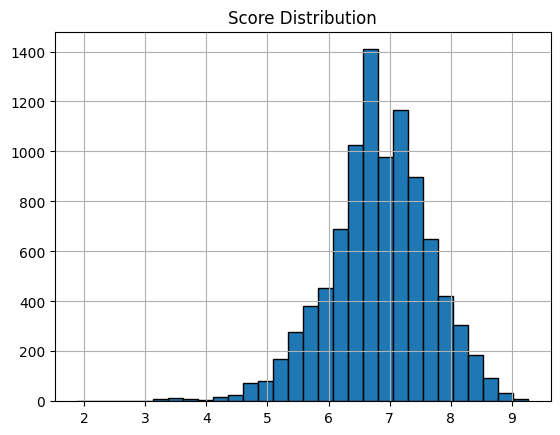

6.819865728900256
6.81


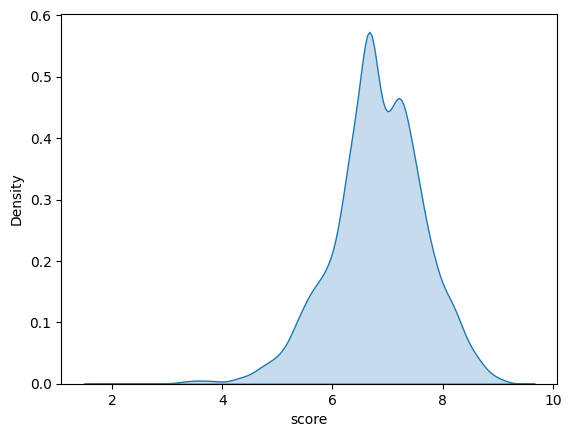

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df['score'].hist(bins=30,edgecolor='black')
plt.title('Score Distribution')
plt.show()

sns.kdeplot(df['score'],fill=True)

print(df['score'].mean())
print(df['score'].median())

# since this is a continuous variable mode is out of question as a means of imputation
# we can see through the graphical representation and the fact that the mean is approximately equal median
# that the data is normally distributed which means we can pretty much fill the the missing score fields with any of the two measures

df['score'] = df['score'].fillna(df['score'].median())

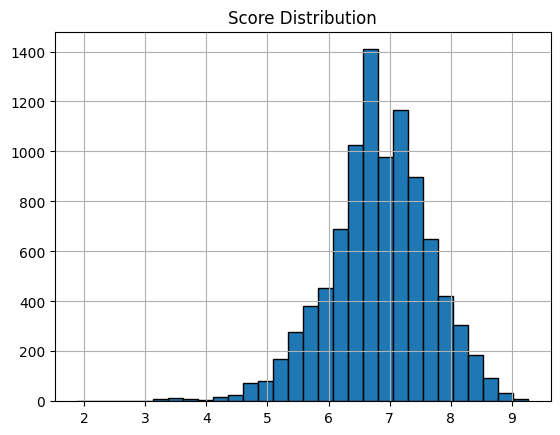

6.819865728900256
6.81


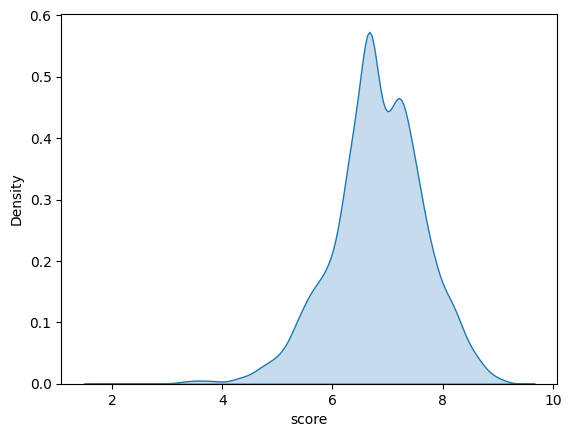

In [ ]:
# visualization to check for the method of imputation for missing episode fields

import matplotlib.pyplot as plt
import seaborn as sns

df['score'].hist(bins=30,edgecolor='black')
plt.title('Score Distribution')
plt.show()

sns.kdeplot(df['score'],fill=True)

print(df['score'].mean())
print(df['score'].median())

# since this is a continuous variable mode is out of question as a means of imputation
# we can see through the graphical representation and the fact that the mean is approximately equal median
# that the data is normally distributed which means we can pretty much fill the the missing score fields with any of the two measures

df['score'] = df['score'].fillna(df['score'].median())

In [ ]:
# checking whether synopsis field contains key indicators to

# setting max column width to None to get all of the text
# the purpose of this code block is to check whether synopsis can be used to different between TV shows and others
# that information will help up decide the method of imputation for number of episodes
# this will also help us decide how to clean the synopsis field

pd.set_option('display.max_colwidth',None)
synopsis_list = df[(df['episodes'] == 1)]["synopsis"]
print(synopsis_list[:40])

1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    Another day, another bountysuch is the life of the often unlucky crew of the Bebop. However, this routine is interrupted when Faye, who is chasing a fairly worthless target on Mars, witnesses an oil tanker suddenly explode, causing mass hysteria. As casualties mount due to a strange disease spreading through the smoke from the blast, a whopping three hundred million woolong price is placed on the hea

In [ ]:
# since we cannot differentiate between movies and TV shows with synopsis field
# we will just populate the missing episode number values with the mode

mode = df['episodes'].mode()[0]
print("Mode for episode numbers: ",mode)

# filling missing episode values with mode
df['episodes'] = df['episodes'].fillna(mode)

Mode for episode numbers:  1.0


In [ ]:
# since synopsis is our most important field we will now visualize its word count
# doing so to help us decide a cut-off for the synopsis length so that we don't lose a lot of data

df['word_count'] = df['synopsis'].str.split().str.len()

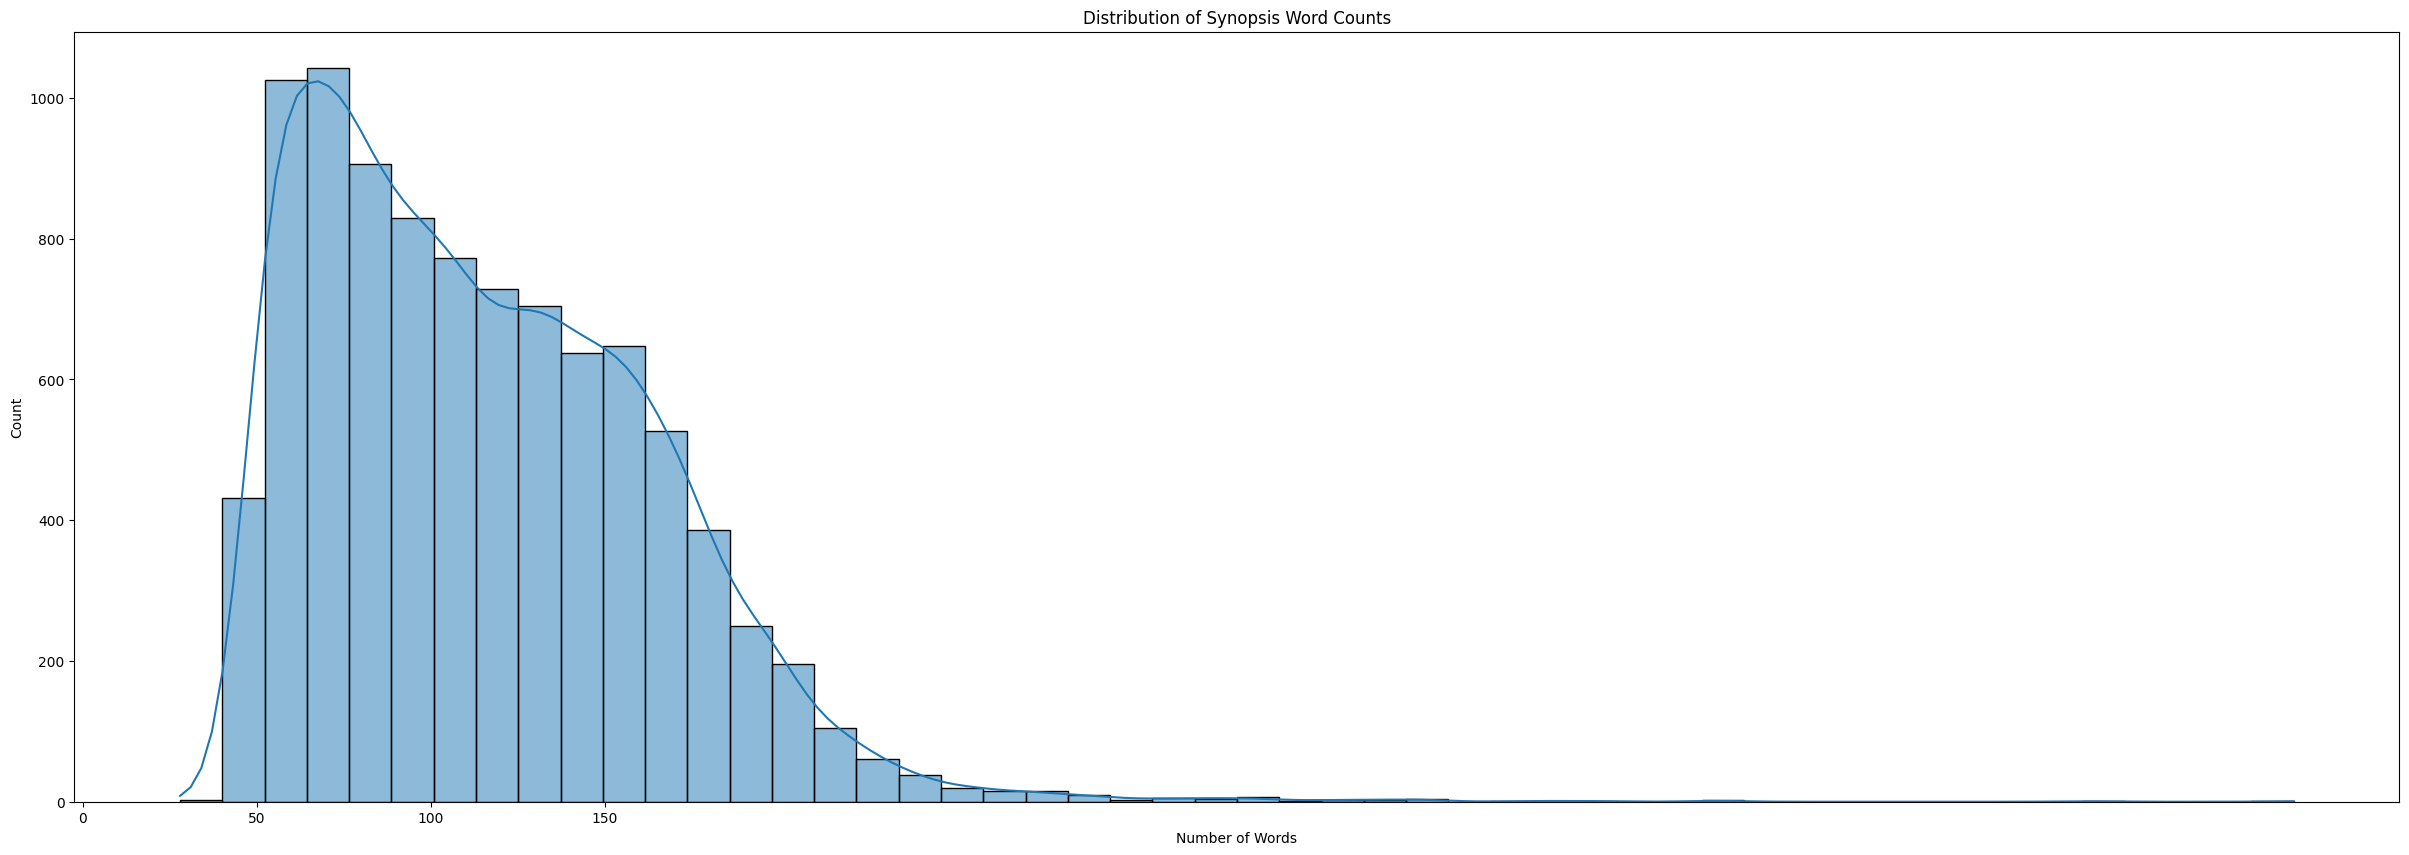

Maximum word count is synopsis:  635
Number of synopsis with lengths less than 50:  149
Percentage of synopsis with lengths less than 50:  1.5878090366581414
Number of synopsis with lengths more than 50 and less than 150 inclusive:  6980
Percentage of synopsis with lengths more than 50 and less than 150 inclusive:  74.38192668371697


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(30,10))
sns.histplot(df['word_count'],bins=50,kde=True)
plt.title('Distribution of Synopsis Word Counts')
plt.xlabel('Number of Words')
plt.xticks(range(0, df['word_count'].max()//4, 50))
plt.show()

print('Maximum word count is synopsis: ',df['word_count'].max())
print('Number of synopsis with lengths less than 50: ',len(df[(df['word_count'] < 50)]))
print('Percentage of synopsis with lengths less than 50: ',100 * (len(df[(df['word_count'] < 50)])/len(df)))
print('Number of synopsis with lengths more than 50 and less than 150 inclusive: ',len(df[(df['word_count'] >= 50) & (df['word_count'] <= 150)]))
print('Percentage of synopsis with lengths more than 50 and less than 150 inclusive: ',100 * (len(df[(df['word_count'] >= 50) & (df['word_count'] <= 150)])/len(df)))

In [ ]:
# deciding cut-off at 50
len_before = len(df)
df = df[(df['word_count'] >= 50)]
len_after = len(df)

print("words removed: ",len_before-len_after)

# checking for any cleanup for NaN values we may have skipped

print(df.isna().sum())

words removed:  149
mal_id          0
title           0
synopsis        0
score           0
popularity      0
episodes        0
status          0
image_url       0
genres          0
themes          0
demographics    0
word_count      0
dtype: int64


In [ ]:
df = df.copy()

# now we will move on to cleaning the synopsis field

df['synopsis'] = df['synopsis'].str.replace(r'[\n\t\r\0]+',' ',regex=True)

df['synopsis'] = df['synopsis'].str.replace(r'\s+',' ',regex=True)

# removing written by and source tags:

df['synopsis'] = df['synopsis'].str.replace(r'\[Written by .*\]$', '', regex=True)
df['synopsis'] = df['synopsis'].str.replace(r'\(Source:.*\)$', '', regex=True)

# removing beginning and trailing whitespace for text fields

df['synopsis'] = df['synopsis'].str.strip()
df['title'] = df['title'].str.strip()

# fixing encoding
for col in ['title', 'synopsis']:
    df[col] = df[col].str.encode('latin-1', errors='ignore').str.decode('utf-8', errors='ignore')

# removing anything that is not a punctuation alphabet or number

df['title'] = df['title'].str.replace(r'[^\x00-\x7F]+', ' ', regex=True)
df['synopsis'] = df['synopsis'].str.replace(r'[^\x00-\x7F]+', ' ', regex=True)

In [ ]:
# visualization for bias detection
# ...


In [ ]:
import pandas as pd
from google.colab import files

df.to_csv("anime_data_cleaned.csv",index=False)
files.download("anime_data_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(df.isna().sum())

mal_id          0
title           0
synopsis        0
score           0
popularity      0
episodes        0
status          0
image_url       0
genres          0
themes          0
demographics    0
word_count      0
dtype: int64


In [ ]:
import pandas as pd

df = pd.read_csv("anime_data_cleaned.csv")

# building embedding text

def build_embedding_text(row):
  tags = []
  if row['themes'] and row['themes'] != 'Unknown':
    tags += row['themes'].split('|')
  if row['genres'] and row['genres'] != 'Unknown':
    tags += row['genres'].split('|')
  if row['demographics'] and row['demographics'] != 'Unknown':
    tags += row['demographics'].split('|')
  tag_string = " ".join(tags)
  return f"{row['synopsis']} {tag_string}".strip()

df['embedding-text'] = df.apply(build_embedding_text,axis=1)
print(df['embedding-text'])

0                                                                             Crime is timeless. By the year 2071, humanity has expanded across the galaxy, filling the surface of other planets with settlements like those on Earth. These new societies are plagued by murder, drug use, and theft, and intergalactic outlaws are hunted by a growing number of tough bounty hunters. Spike Spiegel and Jet Black pursue criminals throughout space to make a humble living. Beneath his goofy and aloof demeanor, Spike is haunted by the weight of his violent past. Meanwhile, Jet manages his own troubled memories while taking care of Spike and the Bebop, their ship. The duo is joined by the beautiful con artist Faye Valentine, odd child Edward Wong Hau Pepelu Tivrusky IV, and Ein, a bioengineered Welsh corgi. While developing bonds and working to catch a colorful cast of criminals, the Bebop crew's lives are disrupted by a menace from Spike's past. As a rival's maniacal plot continues to unravel, Spike 

In [ ]:
# there is a noticeable limitation in the dataset
# I forgot to add the english title and therefore we will do so now
# THIS IS BEING DONE FOR USERS WHO DON'T KNOW ROMAJI TITLES SO BETTER BE THANKFUL

import requests
import time

df['title_english'] = None

ids = df['mal_id'].tolist()
count = 0

for mal_id in ids:
    idx = df[df['mal_id'] == mal_id].index[0]

    # skip if we already have it
    if pd.notna(df.at[idx, 'title_english']):
        continue

    while True:
        res = requests.get(f"https://api.jikan.moe/v4/anime/{mal_id}")

        if res.status_code == 429:
            time.sleep(2)
            continue

        if res.status_code != 200:
            break

        data = res.json()["data"]
        english = data.get("title_english")

        # if no english title fall back to the romaji title
        df.at[idx, 'title_english'] = english if english else df.at[idx, 'title']
        break

    count += 1
    time.sleep(0.4)

    if count % 500 == 0:
        df.to_csv("anime_data.csv", index=False)
        print(f"{count}/{len(ids)} done, {len(ids)-count} remaining")

df.to_csv("anime_data_updated.csv", index=False)
print(f"Done. English titles fetched for {count} anime")
files.download("anime_data_updated.csv")

500/9235 done, 8735 remaining
1000/9235 done, 8235 remaining
1500/9235 done, 7735 remaining
2000/9235 done, 7235 remaining
2500/9235 done, 6735 remaining
3000/9235 done, 6235 remaining
3500/9235 done, 5735 remaining
4000/9235 done, 5235 remaining
4500/9235 done, 4735 remaining
5000/9235 done, 4235 remaining
5500/9235 done, 3735 remaining
6000/9235 done, 3235 remaining
6500/9235 done, 2735 remaining
7000/9235 done, 2235 remaining
7500/9235 done, 1735 remaining
8000/9235 done, 1235 remaining
8500/9235 done, 735 remaining
9000/9235 done, 235 remaining
Done. English titles fetched for 9235 anime


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# checking for NaN values in the newly added column

print(df.isna().sum())


# checking whether all this effort was worth the pain

test_titles = ['one piece', 'naruto', 'demon slayer',
               'attack on titan', 'jujutsu kaisen','dandadan','journal with witch',
               'code geass','haikyuu','chainsaw man','look back','violet evergarden']
print("\n")
for t in test_titles:
    found = df[(df['title'].str.lower().str.contains(t)) | (df['title_english'].str.lower().str.contains(t))]
    print(f"{t}: {len(found)} entries")


mal_id            0
title             0
synopsis          0
score             0
popularity        0
episodes          0
status            0
image_url         0
genres            0
themes            0
demographics      0
word_count        0
embedding-text    0
title_english     0
dtype: int64


one piece: 37 entries
naruto: 25 entries
demon slayer: 7 entries
attack on titan: 15 entries
jujutsu kaisen: 5 entries
dandadan: 2 entries
journal with witch: 1 entries
code geass: 13 entries
haikyuu: 13 entries
chainsaw man: 2 entries
look back: 1 entries
violet evergarden: 4 entries


In [ ]:
# cleaning column title_english

import pandas as pd
from google.colab import files

df = pd.read_csv('anime_data_updated.csv')

# removing beginning and trailing whitespace for text fields
df['title_english'] = df['title_english'].str.strip()

# fixing encoding
df['title_english'] = df['title_english'].str.encode('latin-1', errors='ignore').str.decode('utf-8', errors='ignore')

# removing anything that is not a punctuation alphabet or number
df['title_english'] = df['title_english'].str.replace(r'[^\x00-\x7F]+', ' ', regex=True)

df.to_csv('anime_data_cleaned.csv',index=False)
files.download('anime_data_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# checking the extension types:

# splitting over the dot to create an array of filename and extension and extracting the last element
extensions = df['image_url'].str.rsplit('.', n=1).str[-1]

# to see every unique value and their counts
print(extensions.value_counts())

image_url
jpg    9229
png       6
Name: count, dtype: int64


In [ ]:
print(df["mal_id"].duplicated().sum())

0


In [ ]:
import pandas as pd

df = pd.read_csv("anime_data_cleaned.csv")

# FURTHER CLEANING
# there is a change that placeholder values may group unrelated anime together
# in order to improve the accuracy of semantic search I will be using zero shot classification
# its essentially natural language inference (NFI) to guess the accuracy of a label provided the text

# generating a list of base labels
themes_list = df[df['themes'] != 'Unknown']['themes'].str.split('|').explode().unique().tolist()
demographics_list = df[df['demographics'] != 'Unknown']['demographics'].str.split('|').explode().unique().tolist()

print(themes_list)
print(demographics_list)

['Adult Cast', 'Space', 'Detective', 'Team Sports', 'Love Polygon', 'Visual Arts', 'Racing', 'Psychological', 'Martial Arts', 'School', 'Combat Sports', 'Gag Humor', 'Organized Crime', 'Vampire', 'Historical', 'Military', 'Time Travel', 'Mecha', 'Gore', 'Samurai', 'Super Power', 'Video Game', 'Reincarnation', 'Harem', 'Music', 'Survival', 'Mythology', 'CGDCT', 'Mahou Shoujo', 'Urban Fantasy', 'Reverse Harem', 'Childcare', 'Delinquents', 'Parody', 'Isekai', 'Crossdressing', 'Showbiz', 'Strategy Game', 'Magical Sex Shift', 'Otaku Culture', 'Workplace', 'Iyashikei', 'Performing Arts', 'High Stakes Game', 'Anthropomorphic', 'Idols (Female)', 'Medical', 'Pets', 'Idols (Male)', 'Educational', 'Love Status Quo', 'Villainess']
['Shounen', 'Josei', 'Seinen', 'Shoujo', 'Kids']


In [ ]:
# solving the issue of precision first

import pandas as pd
df = pd.read_csv("anime_data_cleaned.csv")
df = df.rename(columns={'embedding-text': 'embedding_text'})
print(df[df['mal_id'] == 38000]['embedding_text'].values[0])

Ever since the death of his father, the burden of supporting the family has fallen upon Tanjirou Kamado's shoulders. Though living impoverished on a remote mountain, the Kamado family are able to enjoy a relatively peaceful and happy life. One day, Tanjirou decides to go down to the local village to make a little money selling charcoal. On his way back, night falls, forcing Tanjirou to take shelter in the house of a strange man, who warns him of the existence of flesh-eating demons that lurk in the woods at night. When he finally arrives back home the next day, he is met with a horrifying sighthis whole family has been slaughtered. Worse still, the sole survivor is his sister Nezuko, who has been turned into a bloodthirsty demon. Consumed by rage and hatred, Tanjirou swears to avenge his family and stay by his only remaining sibling. Alongside the mysterious group calling themselves the Demon Slayer Corps, Tanjirou will do whatever it takes to slay the demons and protect the remnants o

In [ ]:
print(df['embedding_text'].isna().sum(), "NaN values")
print(df['embedding_text'].eq('').sum(), "empty strings")
print(df['embedding_text'].str.len().describe())  # length distribution
print("\nSample values:")
print(df['embedding_text'].sample(5).tolist())

0 NaN values
0 empty strings
count    9235.000000
mean      716.311099
std       296.746240
min       182.000000
25%       470.000000
50%       669.000000
75%       924.000000
max      3742.000000
Name: embedding_text, dtype: float64

Sample values:
['One morning, an old lady meets a stray cat searching for food in garbage cans and decides to take him back home to give him a proper meal. Despite being surprised to learn that the cat named Tsushima has the ability to speak, she nevertheless chooses to adopt him and entertains all of his whims. Ore, Tsushima details the hilarious adventures of the gluttonous and lazy Tsushima leopard cat in his new foster family. Pets Comedy Seinen', 'Extra Blu-ray/DVD Episode 13 included on vol. 7. In this special episode, Kakeru and the team enter a "Pink Night" instead of red. The "Black Knights" are now "Pink Ero-Rangers," and Lisolette is a bondage driver. The team\'s powers are also warped with an erotic twist. Kakeru can see through clothes; Yuka 

In [ ]:
print(df['embedding_text'].duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
9230    False
9231    False
9232    False
9233    False
9234    False
Name: embedding_text, Length: 9235, dtype: bool


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-mpnet-base-v2")
embeddings = []

anime1_text = df[df["mal_id"] == 1535]["synopsis"].iloc[0]
anime2_text = df[df["mal_id"] == 1575]["synopsis"].iloc[0]

print(anime1_text)
print(anime2_text)

embeddings.append(model.encode(
    [anime1_text],
    normalize_embeddings=True
))

embeddings.append(model.encode(
    [anime2_text],
    normalize_embeddings=True
))

# Compare the first two anime in your list
sim = cosine_similarity(embeddings[0],embeddings[1])
print(f"Similarity between item 0 and 1: {sim[0][0]}")

# Compare item 0 with a completely random string
random_text = model.encode(["The quick brown fox jumps over the lazy dog"],normalize_embeddings=True)
sim_random = cosine_similarity(embeddings[0], random_text)
print(f"Similarity with random text: {sim_random[0][0]}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Brutal murders, petty thefts, and senseless violence pollute the human world. In contrast, the realm of death gods is a humdrum, unchanging gambling den. The ingenious 17-year-old Japanese student Light Yagami and sadistic god of death Ryuk share one belief: their worlds are rotten. For his own amusement, Ryuk drops his Death Note into the human world. Light stumbles upon it, deeming the first of its rules ridiculous: the human whose name is written in this note shall die. However, the temptation is too great, and Light experiments by writing a felon's name, which disturbingly enacts his first murder. Aware of the terrifying godlike power that has fallen into his hands, Lightunder the alias Kirafollows his wicked sense of justice with the ultimate goal of cleansing the world of all evil-doers. The meticulous mastermind detective L is already on his trail, but as Light's brilliance rivals L's, the grand chase for Kira turns into an intense battle of wits that can only end when one of th

In [ ]:
print(df['popularity'].max())

29853


In [ ]:
# I'll be testing an asymmetric model against the current symmetric model
# This is to test whether there is any meaningful increase in similarity scores
# Result: Asymmetric model knocked it out of the park :)

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model1 = SentenceTransformer('all-mpnet-base-v2')
model2 = SentenceTransformer('BAAI/bge-base-en-v1.5')

query = 'something dark and pyschological'

embedding_string = df[df['mal_id'] == 1535]['embedding-text'].tolist()[0]
print(embedding_string)

query_embeddings1 = model1.encode(
    query,
    normalize_embeddings=True
)

embeddings1 = model1.encode(
    embedding_string,
    normalize_embeddings=True
)

query_embeddings2 = model2.encode(
    query,
    normalize_embeddings=True
)

embeddings2 = model2.encode(
    embedding_string,
    normalize_embeddings=True
)

# comparison

similarity_score1 = cosine_similarity(
    query_embeddings1.reshape(1,-1),
    embeddings1.reshape(1,-1)
)

similarity_score2 = cosine_similarity(
    query_embeddings2.reshape(1,-1),
    embeddings2.reshape(1,-1)
)

print('Symmetric Model: ',similarity_score1[0][0])
print('Assymetric Model: ',similarity_score2[0][0])


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Brutal murders, petty thefts, and senseless violence pollute the human world. In contrast, the realm of death gods is a humdrum, unchanging gambling den. The ingenious 17-year-old Japanese student Light Yagami and sadistic god of death Ryuk share one belief: their worlds are rotten. For his own amusement, Ryuk drops his Death Note into the human world. Light stumbles upon it, deeming the first of its rules ridiculous: the human whose name is written in this note shall die. However, the temptation is too great, and Light experiments by writing a felon's name, which disturbingly enacts his first murder. Aware of the terrifying godlike power that has fallen into his hands, Lightunder the alias Kirafollows his wicked sense of justice with the ultimate goal of cleansing the world of all evil-doers. The meticulous mastermind detective L is already on his trail, but as Light's brilliance rivals L's, the grand chase for Kira turns into an intense battle of wits that can only end when one of th

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# prior_model = SentenceTransformer('all-mpnet-base-v2')
model = SentenceTransformer('BAAI/bge-base-en-v1.5')

# STRESS TESTING ASSYMETRIC MODEL:
# the goal is to find the average margins between the similarity scores
# if the delta between similarity scores for relevant and hard negatives is way less than the model is not very discriminative
# we will also be taking a look at the delta between relevant and easy negatives to

test_cases = {
    "political_strategy": {
        "query": "A brilliant strategist uses a newly acquired supernatural power to dismantle a corrupt regime from within.",
        "relevant_id": 1575,      # Code Geass (Focus: Rebellion/Politics)
        "hard_neg_id": 1535,      # Death Note (Focus: Personal Cat-and-Mouse/Police)
        "easy_neg_id": 5680,      # K-On! (Music Club)
        "note": "Tests if it recognizes 'regime/dismantle' vs 'detective/justice'."
    },
    "cyberpunk_justice": {
        "query": "A psychological thriller set in a high-tech dystopia where the line between criminal and lawman is blurred by a surveillance system.",
        "relevant_id": 13601,     # Psycho-Pass (Focus: Surveillance/Law)
        "hard_neg_id": 42310,     # Cyberpunk: Edgerunners (Focus: Crime/Mercenaries)
        "easy_neg_id": 20583,     # Haikyuu!! (Volleyball)
        "note": "Tests 'surveillance/lawman' against general 'cyberpunk crime'."
    },
    "nature_supernatural": {
        "query": "A somber, atmospheric exploration of the balance between humanity and the unseen, ancient spirits of the natural world.",
        "relevant_id": 457,       # Mushishi (Focus: Nature/Ancient)
        "hard_neg_id": 4081,      # Natsume Yuujinchou (Focus: Friendly/Grandma's Book)
        "easy_neg_id": 30276,     # One Punch Man (Superhero)
        "note": "Tests 'nature/ancient' vs 'interpersonal ghost-of-the-week'."
    },
    "cosmic_romance": {
        "query": "A supernatural romance exploring the emotional connection and fate of two individuals separated by cosmic occurrences.",
        "relevant_id": 32281,     # Kimi no Na wa. (Focus: Cosmic/Fate)
        "hard_neg_id": 38826,     # Tenki no Ko (Focus: Weather/Urban)
        "easy_neg_id": 16498,     # Attack on Titan (Giants)
        "note": "Tests for Shinkai-vibe specific nuances: 'cosmic/fate' vs 'weather'."
    },
    "european_manhunt": {
        "query": "A gritty, realistic pursuit of a charismatic but terrifying killer across a cold, post-war European landscape.",
        "relevant_id": 19,        # Monster (Focus: Serial Killer/Europe)
        "hard_neg_id": 37521,     # Vinland Saga (Focus: Revenge/Europe)
        "easy_neg_id": 50265,     # Spy x Family (Comedy/Spy)
        "note": "Tests 'serial killer/post-war' vs 'warrior/medieval'."
    }
}

delta_1 = 0
delta_2 = 0
i = 0

for test in test_cases.items():
  query = test[1]['query']
  relevant = df[df['mal_id'] == test[1]['relevant_id']]['embedding-text'].tolist()[0]
  hard_neg = df[df['mal_id'] == test[1]['hard_neg_id']]['embedding-text'].tolist()[0]
  easy_neg = df[df['mal_id'] == test[1]['easy_neg_id']]['embedding-text'].tolist()[0]
  query_embeddings = model.encode(query,normalize_embeddings=True)
  relevant_embeddings = model.encode(relevant,normalize_embeddings=True)
  hard_neg_embeddings = model.encode(hard_neg,normalize_embeddings=True)
  easy_neg_embeddings = model.encode(easy_neg,normalize_embeddings=True)
  relevant_score = cosine_similarity(query_embeddings.reshape(1,-1),relevant_embeddings.reshape(1,-1))[0][0]
  hard_neg_score = cosine_similarity(query_embeddings.reshape(1,-1),hard_neg_embeddings.reshape(1,-1))[0][0]
  easy_neg_score = cosine_similarity(query_embeddings.reshape(1,-1),easy_neg_embeddings.reshape(1,-1))[0][0]

  print('delta between relevant and hard negative: ',relevant_score - hard_neg_score)
  print('delta between relevant and easy negative: ',relevant_score - easy_neg_score)

  delta_1 += relevant_score - hard_neg_score
  delta_2 += relevant_score - easy_neg_score

  i += 1

print('Average delta between relevant and hard negative: ',delta_1/i)
print('Average delta between relevant and easy negative: ',delta_2/i)



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


delta between relevant and hard negative:  0.040086508
delta between relevant and easy negative:  0.14997414
delta between relevant and hard negative:  0.12207389
delta between relevant and easy negative:  0.17107594
delta between relevant and hard negative:  0.026591063
delta between relevant and easy negative:  0.041561007
delta between relevant and hard negative:  -0.11169958
delta between relevant and easy negative:  -0.07361114
delta between relevant and hard negative:  -0.10339761
delta between relevant and easy negative:  -0.02000755
Average delta between relevant and hard negative:  -0.005269146
Average delta between relevant and easy negative:  0.053798478


In [ ]:
# this is the same test but with prepended instruction in query:

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# prior_model = SentenceTransformer('all-mpnet-base-v2')
model = SentenceTransformer('BAAI/bge-base-en-v1.5')

# STRESS TESTING ASSYMETRIC MODEL:
# the goal is to find the average margins between the similarity scores
# if the delta between similarity scores for relevant and hard negatives is way less than the model is not very discriminative
# we will also be taking a look at the delta between relevant and easy negatives to

test_cases = {
    "political_strategy": {
        "query": "A brilliant strategist uses a newly acquired supernatural power to dismantle a corrupt regime from within.",
        "relevant_id": 1575,      # Code Geass (Focus: Rebellion/Politics)
        "hard_neg_id": 1535,      # Death Note (Focus: Personal Cat-and-Mouse/Police)
        "easy_neg_id": 5680,      # K-On! (Music Club)
        "note": "Tests if it recognizes 'regime/dismantle' vs 'detective/justice'."
    },
    "cyberpunk_justice": {
        "query": "A psychological thriller set in a high-tech dystopia where the line between criminal and lawman is blurred by a surveillance system.",
        "relevant_id": 13601,     # Psycho-Pass (Focus: Surveillance/Law)
        "hard_neg_id": 42310,     # Cyberpunk: Edgerunners (Focus: Crime/Mercenaries)
        "easy_neg_id": 20583,     # Haikyuu!! (Volleyball)
        "note": "Tests 'surveillance/lawman' against general 'cyberpunk crime'."
    },
    "nature_supernatural": {
        "query": "A somber, atmospheric exploration of the balance between humanity and the unseen, ancient spirits of the natural world.",
        "relevant_id": 457,       # Mushishi (Focus: Nature/Ancient)
        "hard_neg_id": 4081,      # Natsume Yuujinchou (Focus: Friendly/Grandma's Book)
        "easy_neg_id": 30276,     # One Punch Man (Superhero)
        "note": "Tests 'nature/ancient' vs 'interpersonal ghost-of-the-week'."
    },
    "cosmic_romance": {
        "query": "A supernatural romance exploring the emotional connection and fate of two individuals separated by cosmic occurrences.",
        "relevant_id": 32281,     # Kimi no Na wa. (Focus: Cosmic/Fate)
        "hard_neg_id": 38826,     # Tenki no Ko (Focus: Weather/Urban)
        "easy_neg_id": 16498,     # Attack on Titan (Giants)
        "note": "Tests for Shinkai-vibe specific nuances: 'cosmic/fate' vs 'weather'."
    },
    "european_manhunt": {
        "query": "A gritty, realistic pursuit of a charismatic but terrifying killer across a cold, post-war European landscape.",
        "relevant_id": 19,        # Monster (Focus: Serial Killer/Europe)
        "hard_neg_id": 37521,     # Vinland Saga (Focus: Revenge/Europe)
        "easy_neg_id": 50265,     # Spy x Family (Comedy/Spy)
        "note": "Tests 'serial killer/post-war' vs 'warrior/medieval'."
    }
}

delta_1 = 0
delta_2 = 0
i = 0

for test in test_cases.items():
  query = test[1]['query']
  query = "Represent this sentence for searching relevant passages: " + query
  relevant = df[df['mal_id'] == test[1]['relevant_id']]['embedding-text'].tolist()[0]
  hard_neg = df[df['mal_id'] == test[1]['hard_neg_id']]['embedding-text'].tolist()[0]
  easy_neg = df[df['mal_id'] == test[1]['easy_neg_id']]['embedding-text'].tolist()[0]
  query_embeddings = model.encode(query,normalize_embeddings=True)
  relevant_embeddings = model.encode(relevant,normalize_embeddings=True)
  hard_neg_embeddings = model.encode(hard_neg,normalize_embeddings=True)
  easy_neg_embeddings = model.encode(easy_neg,normalize_embeddings=True)
  relevant_score = cosine_similarity(query_embeddings.reshape(1,-1),relevant_embeddings.reshape(1,-1))[0][0]
  hard_neg_score = cosine_similarity(query_embeddings.reshape(1,-1),hard_neg_embeddings.reshape(1,-1))[0][0]
  easy_neg_score = cosine_similarity(query_embeddings.reshape(1,-1),easy_neg_embeddings.reshape(1,-1))[0][0]

  print('delta between relevant and hard negative: ',relevant_score - hard_neg_score)
  print('delta between relevant and easy negative: ',relevant_score - easy_neg_score)

  delta_1 += relevant_score - hard_neg_score
  delta_2 += relevant_score - easy_neg_score

  i += 1

print('Average delta between relevant and hard negative: ',delta_1/i)
print('Average delta between relevant and easy negative: ',delta_2/i)



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


delta between relevant and hard negative:  0.02211088
delta between relevant and easy negative:  0.15140134
delta between relevant and hard negative:  0.0969668
delta between relevant and easy negative:  0.18130916
delta between relevant and hard negative:  0.060372174
delta between relevant and easy negative:  0.088846564
delta between relevant and hard negative:  -0.09901738
delta between relevant and easy negative:  -0.027984262
delta between relevant and hard negative:  -0.110928416
delta between relevant and easy negative:  -0.03356549
Average delta between relevant and hard negative:  -0.0060991882
Average delta between relevant and easy negative:  0.072001465


In [ ]:
# checking whether the model has any discriminatory power at all

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('BAAI/bge-base-en-v1.5')

# encoding random text
random_query = "The quick brown fox jumps over the lazy dog"
random_embedding_string = df[df['mal_id'] == 1535]['embedding-text'].tolist()[0]

emb1 = model.encode(random_query, normalize_embeddings=True)
emb2 = model.encode(random_embedding_string, normalize_embeddings=True)

random_sim = cosine_similarity(emb1.reshape(1,-1), emb2.reshape(1,-1))
print(f"Random Baseline Similarity: {random_sim[0][0]}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Random Baseline Similarity: 0.33851373195648193


In [ ]:
# this is the same test but with mpnet model:

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-mpnet-base-v2')

# STRESS TESTING ASSYMETRIC MODEL:
# the goal is to find the average margins between the similarity scores
# if the delta between similarity scores for relevant and hard negatives is way less than the model is not very discriminative
# we will also be taking a look at the delta between relevant and easy negatives to

test_cases = {
    "political_strategy": {
        "query": "A brilliant strategist uses a newly acquired supernatural power to dismantle a corrupt regime from within.",
        "relevant_id": 1575,      # Code Geass (Focus: Rebellion/Politics)
        "hard_neg_id": 1535,      # Death Note (Focus: Personal Cat-and-Mouse/Police)
        "easy_neg_id": 5680,      # K-On! (Music Club)
        "note": "Tests if it recognizes 'regime/dismantle' vs 'detective/justice'."
    },
    "cyberpunk_justice": {
        "query": "A psychological thriller set in a high-tech dystopia where the line between criminal and lawman is blurred by a surveillance system.",
        "relevant_id": 13601,     # Psycho-Pass (Focus: Surveillance/Law)
        "hard_neg_id": 42310,     # Cyberpunk: Edgerunners (Focus: Crime/Mercenaries)
        "easy_neg_id": 20583,     # Haikyuu!! (Volleyball)
        "note": "Tests 'surveillance/lawman' against general 'cyberpunk crime'."
    },
    "nature_supernatural": {
        "query": "A somber, atmospheric exploration of the balance between humanity and the unseen, ancient spirits of the natural world.",
        "relevant_id": 457,       # Mushishi (Focus: Nature/Ancient)
        "hard_neg_id": 4081,      # Natsume Yuujinchou (Focus: Friendly/Grandma's Book)
        "easy_neg_id": 30276,     # One Punch Man (Superhero)
        "note": "Tests 'nature/ancient' vs 'interpersonal ghost-of-the-week'."
    },
    "cosmic_romance": {
        "query": "A supernatural romance exploring the emotional connection and fate of two individuals separated by cosmic occurrences.",
        "relevant_id": 32281,     # Kimi no Na wa. (Focus: Cosmic/Fate)
        "hard_neg_id": 38826,     # Tenki no Ko (Focus: Weather/Urban)
        "easy_neg_id": 16498,     # Attack on Titan (Giants)
        "note": "Tests for Shinkai-vibe specific nuances: 'cosmic/fate' vs 'weather'."
    },
    "european_manhunt": {
        "query": "A gritty, realistic pursuit of a charismatic but terrifying killer across a cold, post-war European landscape.",
        "relevant_id": 19,        # Monster (Focus: Serial Killer/Europe)
        "hard_neg_id": 37521,     # Vinland Saga (Focus: Revenge/Europe)
        "easy_neg_id": 50265,     # Spy x Family (Comedy/Spy)
        "note": "Tests 'serial killer/post-war' vs 'warrior/medieval'."
    }
}

delta_1 = 0
delta_2 = 0
i = 0

for test in test_cases.items():
  query = test[1]['query']
  relevant = df[df['mal_id'] == test[1]['relevant_id']]['embedding-text'].tolist()[0]
  hard_neg = df[df['mal_id'] == test[1]['hard_neg_id']]['embedding-text'].tolist()[0]
  easy_neg = df[df['mal_id'] == test[1]['easy_neg_id']]['embedding-text'].tolist()[0]
  query_embeddings = model.encode(query,normalize_embeddings=True)
  relevant_embeddings = model.encode(relevant,normalize_embeddings=True)
  hard_neg_embeddings = model.encode(hard_neg,normalize_embeddings=True)
  easy_neg_embeddings = model.encode(easy_neg,normalize_embeddings=True)
  relevant_score = cosine_similarity(query_embeddings.reshape(1,-1),relevant_embeddings.reshape(1,-1))[0][0]
  hard_neg_score = cosine_similarity(query_embeddings.reshape(1,-1),hard_neg_embeddings.reshape(1,-1))[0][0]
  easy_neg_score = cosine_similarity(query_embeddings.reshape(1,-1),easy_neg_embeddings.reshape(1,-1))[0][0]

  print('delta between relevant and hard negative: ',relevant_score - hard_neg_score)
  print('delta between relevant and easy negative: ',relevant_score - easy_neg_score)

  delta_1 += relevant_score - hard_neg_score
  delta_2 += relevant_score - easy_neg_score

  i += 1

print('Average delta between relevant and hard negative: ',delta_1/i)
print('Average delta between relevant and easy negative: ',delta_2/i)



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


delta between relevant and hard negative:  0.061011136
delta between relevant and easy negative:  0.29774678
delta between relevant and hard negative:  0.10100615
delta between relevant and easy negative:  0.39978725
delta between relevant and hard negative:  0.07579431
delta between relevant and easy negative:  0.27690944
delta between relevant and hard negative:  -0.20673472
delta between relevant and easy negative:  -0.061520696
delta between relevant and hard negative:  -0.15744203
delta between relevant and easy negative:  0.06352347
Average delta between relevant and hard negative:  -0.02527303
Average delta between relevant and easy negative:  0.19528924


In [ ]:
# this is the same test but with a different assymetric model:

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('multi-qa-MiniLM-L6-cos-v1')

# STRESS TESTING ASSYMETRIC MODEL:
# the goal is to find the average margins between the similarity scores
# if the delta between similarity scores for relevant and hard negatives is way less than the model is not very discriminative
# we will also be taking a look at the delta between relevant and easy negatives to

test_cases = {
    "political_strategy": {
        "query": "A brilliant strategist uses a newly acquired supernatural power to dismantle a corrupt regime from within.",
        "relevant_id": 1575,      # Code Geass (Focus: Rebellion/Politics)
        "hard_neg_id": 1535,      # Death Note (Focus: Personal Cat-and-Mouse/Police)
        "easy_neg_id": 5680,      # K-On! (Music Club)
        "note": "Tests if it recognizes 'regime/dismantle' vs 'detective/justice'."
    },
    "cyberpunk_justice": {
        "query": "A psychological thriller set in a high-tech dystopia where the line between criminal and lawman is blurred by a surveillance system.",
        "relevant_id": 13601,     # Psycho-Pass (Focus: Surveillance/Law)
        "hard_neg_id": 42310,     # Cyberpunk: Edgerunners (Focus: Crime/Mercenaries)
        "easy_neg_id": 20583,     # Haikyuu!! (Volleyball)
        "note": "Tests 'surveillance/lawman' against general 'cyberpunk crime'."
    },
    "nature_supernatural": {
        "query": "A somber, atmospheric exploration of the balance between humanity and the unseen, ancient spirits of the natural world.",
        "relevant_id": 457,       # Mushishi (Focus: Nature/Ancient)
        "hard_neg_id": 4081,      # Natsume Yuujinchou (Focus: Friendly/Grandma's Book)
        "easy_neg_id": 30276,     # One Punch Man (Superhero)
        "note": "Tests 'nature/ancient' vs 'interpersonal ghost-of-the-week'."
    },
    "cosmic_romance": {
        "query": "A supernatural romance exploring the emotional connection and fate of two individuals separated by cosmic occurrences.",
        "relevant_id": 32281,     # Kimi no Na wa. (Focus: Cosmic/Fate)
        "hard_neg_id": 38826,     # Tenki no Ko (Focus: Weather/Urban)
        "easy_neg_id": 16498,     # Attack on Titan (Giants)
        "note": "Tests for Shinkai-vibe specific nuances: 'cosmic/fate' vs 'weather'."
    },
    "european_manhunt": {
        "query": "A gritty, realistic pursuit of a charismatic but terrifying killer across a cold, post-war European landscape.",
        "relevant_id": 19,        # Monster (Focus: Serial Killer/Europe)
        "hard_neg_id": 37521,     # Vinland Saga (Focus: Revenge/Europe)
        "easy_neg_id": 50265,     # Spy x Family (Comedy/Spy)
        "note": "Tests 'serial killer/post-war' vs 'warrior/medieval'."
    }
}

delta_1 = 0
delta_2 = 0
i = 0

for test in test_cases.items():
  query = test[1]['query']
  relevant = df[df['mal_id'] == test[1]['relevant_id']]['embedding-text'].tolist()[0]
  hard_neg = df[df['mal_id'] == test[1]['hard_neg_id']]['embedding-text'].tolist()[0]
  easy_neg = df[df['mal_id'] == test[1]['easy_neg_id']]['embedding-text'].tolist()[0]
  query_embeddings = model.encode(query,normalize_embeddings=True)
  relevant_embeddings = model.encode(relevant,normalize_embeddings=True)
  hard_neg_embeddings = model.encode(hard_neg,normalize_embeddings=True)
  easy_neg_embeddings = model.encode(easy_neg,normalize_embeddings=True)
  relevant_score = cosine_similarity(query_embeddings.reshape(1,-1),relevant_embeddings.reshape(1,-1))[0][0]
  hard_neg_score = cosine_similarity(query_embeddings.reshape(1,-1),hard_neg_embeddings.reshape(1,-1))[0][0]
  easy_neg_score = cosine_similarity(query_embeddings.reshape(1,-1),easy_neg_embeddings.reshape(1,-1))[0][0]

  print('delta between relevant and hard negative: ',relevant_score - hard_neg_score)
  print('delta between relevant and easy negative: ',relevant_score - easy_neg_score)

  delta_1 += relevant_score - hard_neg_score
  delta_2 += relevant_score - easy_neg_score

  i += 1

print('Average delta between relevant and hard negative: ',delta_1/i)
print('Average delta between relevant and easy negative: ',delta_2/i)



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

delta between relevant and hard negative:  -0.11508483
delta between relevant and easy negative:  0.075273514
delta between relevant and hard negative:  0.16022894
delta between relevant and easy negative:  0.5126855
delta between relevant and hard negative:  -0.013645381
delta between relevant and easy negative:  0.14705037
delta between relevant and hard negative:  -0.12578273
delta between relevant and easy negative:  -0.0070233196
delta between relevant and hard negative:  -0.070866436
delta between relevant and easy negative:  -0.0719358
Average delta between relevant and hard negative:  -0.033030085
Average delta between relevant and easy negative:  0.13121004


In [ ]:
# this is the same test but with a different assymetric model:

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('mixedbread-ai/mxbai-embed-large-v1')

# STRESS TESTING ASSYMETRIC MODEL:
# the goal is to find the average margins between the similarity scores
# if the delta between similarity scores for relevant and hard negatives is way less than the model is not very discriminative
# we will also be taking a look at the delta between relevant and easy negatives to

test_cases = {
    "political_strategy": {
        "query": "A brilliant strategist uses a newly acquired supernatural power to dismantle a corrupt regime from within.",
        "relevant_id": 1575,      # Code Geass (Focus: Rebellion/Politics)
        "hard_neg_id": 1535,      # Death Note (Focus: Personal Cat-and-Mouse/Police)
        "easy_neg_id": 5680,      # K-On! (Music Club)
        "note": "Tests if it recognizes 'regime/dismantle' vs 'detective/justice'."
    },
    "cyberpunk_justice": {
        "query": "A psychological thriller set in a high-tech dystopia where the line between criminal and lawman is blurred by a surveillance system.",
        "relevant_id": 13601,     # Psycho-Pass (Focus: Surveillance/Law)
        "hard_neg_id": 42310,     # Cyberpunk: Edgerunners (Focus: Crime/Mercenaries)
        "easy_neg_id": 20583,     # Haikyuu!! (Volleyball)
        "note": "Tests 'surveillance/lawman' against general 'cyberpunk crime'."
    },
    "nature_supernatural": {
        "query": "A somber, atmospheric exploration of the balance between humanity and the unseen, ancient spirits of the natural world.",
        "relevant_id": 457,       # Mushishi (Focus: Nature/Ancient)
        "hard_neg_id": 4081,      # Natsume Yuujinchou (Focus: Friendly/Grandma's Book)
        "easy_neg_id": 30276,     # One Punch Man (Superhero)
        "note": "Tests 'nature/ancient' vs 'interpersonal ghost-of-the-week'."
    },
    "cosmic_romance": {
        "query": "A supernatural romance exploring the emotional connection and fate of two individuals separated by cosmic occurrences.",
        "relevant_id": 32281,     # Kimi no Na wa. (Focus: Cosmic/Fate)
        "hard_neg_id": 38826,     # Tenki no Ko (Focus: Weather/Urban)
        "easy_neg_id": 16498,     # Attack on Titan (Giants)
        "note": "Tests for Shinkai-vibe specific nuances: 'cosmic/fate' vs 'weather'."
    },
    "european_manhunt": {
        "query": "A gritty, realistic pursuit of a charismatic but terrifying killer across a cold, post-war European landscape.",
        "relevant_id": 19,        # Monster (Focus: Serial Killer/Europe)
        "hard_neg_id": 37521,     # Vinland Saga (Focus: Revenge/Europe)
        "easy_neg_id": 50265,     # Spy x Family (Comedy/Spy)
        "note": "Tests 'serial killer/post-war' vs 'warrior/medieval'."
    }
}

delta_1 = 0
delta_2 = 0
i = 0

for test in test_cases.items():
  query = test[1]['query']
  relevant = df[df['mal_id'] == test[1]['relevant_id']]['embedding-text'].tolist()[0]
  hard_neg = df[df['mal_id'] == test[1]['hard_neg_id']]['embedding-text'].tolist()[0]
  easy_neg = df[df['mal_id'] == test[1]['easy_neg_id']]['embedding-text'].tolist()[0]
  query_embeddings = model.encode(query,normalize_embeddings=True)
  relevant_embeddings = model.encode(relevant,normalize_embeddings=True)
  hard_neg_embeddings = model.encode(hard_neg,normalize_embeddings=True)
  easy_neg_embeddings = model.encode(easy_neg,normalize_embeddings=True)
  relevant_score = cosine_similarity(query_embeddings.reshape(1,-1),relevant_embeddings.reshape(1,-1))[0][0]
  hard_neg_score = cosine_similarity(query_embeddings.reshape(1,-1),hard_neg_embeddings.reshape(1,-1))[0][0]
  easy_neg_score = cosine_similarity(query_embeddings.reshape(1,-1),easy_neg_embeddings.reshape(1,-1))[0][0]

  print('delta between relevant and hard negative: ',relevant_score - hard_neg_score)
  print('delta between relevant and easy negative: ',relevant_score - easy_neg_score)

  delta_1 += relevant_score - hard_neg_score
  delta_2 += relevant_score - easy_neg_score

  i += 1

print('Average delta between relevant and hard negative: ',delta_1/i)
print('Average delta between relevant and easy negative: ',delta_2/i)



modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/677 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

delta between relevant and hard negative:  0.0012998328211475396
delta between relevant and easy negative:  0.17340711372331524
delta between relevant and hard negative:  0.006948573823958748
delta between relevant and easy negative:  0.24470755542524114
delta between relevant and hard negative:  0.06380479201292955
delta between relevant and easy negative:  0.1581998191192578
delta between relevant and hard negative:  -0.0541936274907211
delta between relevant and easy negative:  0.04340087878808985
delta between relevant and hard negative:  -0.06688623731767274
delta between relevant and easy negative:  0.020199499986761404
Average delta between relevant and hard negative:  -0.0098053332300716
Average delta between relevant and easy negative:  0.1279829734085331


In [ ]:
# getting unique genres to implement genre tags in frontend
list = df['genres'].str.split('|').explode().unique().tolist()
print(list)
print(df['score'].min(),df['score'].max())

['Action', 'Award Winning', 'Sci-Fi', 'Adventure', 'Drama', 'Mystery', 'Supernatural', 'Fantasy', 'Sports', 'Comedy', 'Romance', 'Suspense', 'Ecchi', 'Avant Garde', 'Gourmet', 'Horror', 'Girls Love', 'Boys Love', 'Hentai', 'Slice of Life', 'Erotica']
1.89 9.27


In [ ]:
# removing any lewd anime before I get called out
# ITS NOT MY FAULT SUCH ANIME EXIST AND THAT I DIDN'T THINK THIS THROUGH EARLIER

import pandas as pd
from google.colab import files
import re

df = pd.read_csv('anime_data_cleaned.csv')

target_genres = ['Hentai', 'Erotica', 'Girls Love','Boys Love']
genre_regex = '|'.join([re.escape(g) for g in target_genres])

matches = df[df['genres'].str.contains(genre_regex, na=False)]
count = len(matches)

print(f"Number of anime containing any of {target_genres}: {count}")

df = df[~df['genres'].str.contains(genre_regex, na=False)]

print('Length after dropping anime: ',len(df))

df.to_csv('anime_data_cleaned.csv')
files.download('anime_data_cleaned.csv')

Number of anime containing any of ['Hentai', 'Erotica', 'Girls Love', 'Boys Love']: 1052
Length after dropping anime:  8183


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>